  1D Harmonic Oscillator Wigner Sampling Test
  omega       = 0.01  a.u.
  temperature = 300 K
  beta        = 1052.5835  a.u.
  coth(bw/2)  = 1.000054
  Exact sigma_q  = 7.071258  a.u.
  Exact sigma_p  = 0.070713  a.u.
  Exact <E>      = 0.005000  a.u.

  Sampled (N = 10000)
  mean(q)         = -0.014411   (expected ~ 0)
  mean(p)         = 0.000858   (expected ~ 0)

  sigma_q sampled = 7.017539
  sigma_q exact   = 7.071258
  error           = 0.760 %

  sigma_p sampled = 0.071901
  sigma_p exact   = 0.070713
  error           = 1.681 %

  <E> sampled     = 0.005048
  <E> exact       = 0.005000
  error           = 0.946 %

  Test Results (tolerance = 2%)
-------------------------------------------------------
  sigma_q     error = 0.760%   [PASS]
  sigma_p     error = 1.681%   [PASS]
  <E>         error = 0.946%   [PASS]
-------------------------------------------------------
  Overall: ALL TESTS PASSED


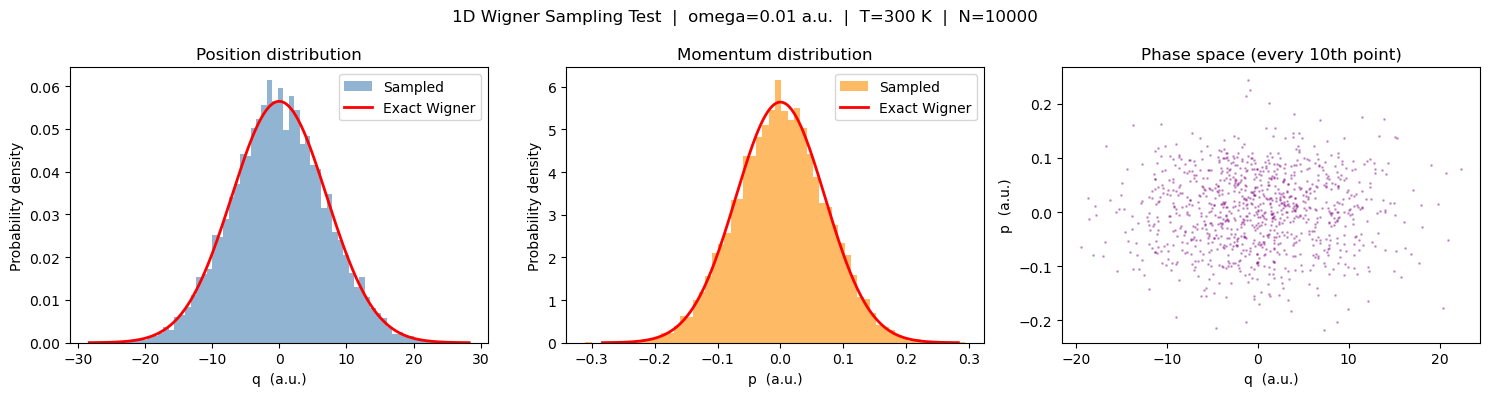


  Plot saved as wigner_1d_test.png


In [10]:
# test_wigner_1d.py
"""
Test wigner.py using a 1D harmonic oscillator.
Validates that:
1. Mean of q and p are zero
2. Variance of q and p match the exact Wigner distribution
3. Average energy matches the expected quantum harmonic oscillator energy
4. Distribution shape is Gaussian (visual check)
"""

import numpy as np
import matplotlib.pyplot as plt
from wigner import generate_wigner_ics

# ── Boltzmann constant in atomic units ──
kB_au = 3.1668114e-6   # Hartree / Kelvin


# PARAMETERS

omega       = 0.01     # frequency in atomic units (~2200 cm-1, typical C-H stretch)
temperature = 300    # Kelvin
ntraj       = 10000    # number of samples (more = better statistics)
seed        = 42

# ANALYTICAL REFERENCE VALUES

beta        = 1.0 / (kB_au * temperature)
coth        = 1.0 / np.tanh(beta * omega / 2.0)

sigma_q_exact = np.sqrt(coth / (2.0 * omega))
sigma_p_exact = np.sqrt(omega * coth / 2.0)
E_exact       = (omega / 2.0) * coth    # <E> = (hbar*omega/2) * coth(beta*omega/2)


print("  1D Harmonic Oscillator Wigner Sampling Test")

print(f"  omega       = {omega}  a.u.")
print(f"  temperature = {temperature} K")
print(f"  beta        = {beta:.4f}  a.u.")
print(f"  coth(bw/2)  = {coth:.6f}")

print(f"  Exact sigma_q  = {sigma_q_exact:.6f}  a.u.")
print(f"  Exact sigma_p  = {sigma_p_exact:.6f}  a.u.")
print(f"  Exact <E>      = {E_exact:.6f}  a.u.")


# WIGNER SAMPLING using wigner.py module
# 1D case: q_eq = [0], D_cart = [[1]], D_p = [[1]]

q_eq   = np.array([0.0])
D_cart = np.array([[1.0]])      # identity: no transformation
D_p    = np.array([[1.0]])
omega_arr = np.array([omega])

ics = generate_wigner_ics(
    q_eq=q_eq,
    D_cart=D_cart,
    D_p=D_p,
    omega=omega_arr,
    temperature=temperature,
    ntraj=ntraj,
    seed=seed,
    kB_value=kB_au
)

# COLLECT RESULTS

q_samples = np.array([ic["q"][0] for ic in ics])
p_samples = np.array([ic["p"][0] for ic in ics])

mean_q    = np.mean(q_samples)
mean_p    = np.mean(p_samples)
sigma_q   = np.std(q_samples)
sigma_p   = np.std(p_samples)
E_samples = 0.5 * p_samples**2 + 0.5 * omega**2 * q_samples**2
mean_E    = np.mean(E_samples)

# PRINT COMPARISON

print(f"\n  Sampled (N = {ntraj})")

print(f"  mean(q)         = {mean_q:.6f}   (expected ~ 0)")
print(f"  mean(p)         = {mean_p:.6f}   (expected ~ 0)")
print()
print(f"  sigma_q sampled = {sigma_q:.6f}")
print(f"  sigma_q exact   = {sigma_q_exact:.6f}")
print(f"  error           = {abs(sigma_q - sigma_q_exact)/sigma_q_exact * 100:.3f} %")
print()
print(f"  sigma_p sampled = {sigma_p:.6f}")
print(f"  sigma_p exact   = {sigma_p_exact:.6f}")
print(f"  error           = {abs(sigma_p - sigma_p_exact)/sigma_p_exact * 100:.3f} %")
print()
print(f"  <E> sampled     = {mean_E:.6f}")
print(f"  <E> exact       = {E_exact:.6f}")
print(f"  error           = {abs(mean_E - E_exact)/E_exact * 100:.3f} %")


# PASS / FAIL CHECK

tol = 2.0  # percent
tests = {
    "sigma_q": abs(sigma_q - sigma_q_exact) / sigma_q_exact * 100,
    "sigma_p": abs(sigma_p - sigma_p_exact) / sigma_p_exact * 100,
    "<E>":     abs(mean_E  - E_exact)       / E_exact       * 100,
}

print("\n  Test Results (tolerance = 2%)")
print("-" * 55)
all_passed = True
for name, err in tests.items():
    status = "PASS" if err < tol else "FAIL"
    if status == "FAIL":
        all_passed = False
    print(f"  {name:<10}  error = {err:.3f}%   [{status}]")

print("-" * 55)
print(f"  Overall: {'ALL TESTS PASSED' if all_passed else 'SOME TESTS FAILED'}")
print("=" * 55)

# ─────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"1D Wigner Sampling Test  |  omega={omega} a.u.  |  T={temperature} K  |  N={ntraj}", fontsize=12)

# --- q distribution ---
x_q = np.linspace(-4*sigma_q_exact, 4*sigma_q_exact, 300)
gauss_q = (1/(sigma_q_exact * np.sqrt(2*np.pi))) * np.exp(-x_q**2 / (2*sigma_q_exact**2))

axes[0].hist(q_samples, bins=60, density=True, alpha=0.6, color="steelblue", label="Sampled")
axes[0].plot(x_q, gauss_q, "r-", lw=2, label="Exact Wigner")
axes[0].set_xlabel("q  (a.u.)")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Position distribution")
axes[0].legend()

# --- p distribution ---
x_p = np.linspace(-4*sigma_p_exact, 4*sigma_p_exact, 300)
gauss_p = (1/(sigma_p_exact * np.sqrt(2*np.pi))) * np.exp(-x_p**2 / (2*sigma_p_exact**2))

axes[1].hist(p_samples, bins=60, density=True, alpha=0.6, color="darkorange", label="Sampled")
axes[1].plot(x_p, gauss_p, "r-", lw=2, label="Exact Wigner")
axes[1].set_xlabel("p  (a.u.)")
axes[1].set_ylabel("Probability density")
axes[1].set_title("Momentum distribution")
axes[1].legend()

# --- Phase space ---
axes[2].scatter(q_samples[::10], p_samples[::10], s=1, alpha=0.3, color="purple")
axes[2].set_xlabel("q  (a.u.)")
axes[2].set_ylabel("p  (a.u.)")
axes[2].set_title("Phase space (every 10th point)")

plt.tight_layout()
plt.savefig("wigner_1d_test.png", dpi=150)
plt.show()
print("\n  Plot saved as wigner_1d_test.png")
